# Ultimate Real-Time Sepsis Detection Architecture
This notebook encapsulates the entire end-to-end pipeline for predicting Sepsis in real-time using IoT physiological sensors. 

### Key Features Included:
1. **IoT Stream Simulation**: Simulates high-frequency incoming data from wearable/hospital sensors.
2. **Advanced Feature Engineering**: Comprehensive features including rates of change, variability, cross-parameter relationships, baseline deviations, and sliding window statistics.
3. **Two-Stage Person-Specific Model**:
   - **Stage 1**: Anomaly Detection (Isolation Forest) - detects "something is wrong"
   - **Stage 2**: Condition Differentiation (Random Forest Classifier) - classifies Normal/Mild infection/Severe systemic
4. **Clinical Logic Layer**: qSOFA-inspired scoring for clinical validation.
5. **Sliding Window Inference**: Performs ultra-fast real-time inference on the most recent chunks of data.
6. **Simulated Visualization**: Plots the deterioration and anomaly alerts over time.

### Justification for Approach:
We differentiate conditions using temporal dynamics (rapid vs. slow changes), variability collapse (HRV deterioration), multi-parameter coupling (correlations and ratios), and clinical scoring (qSOFA-inspired). This provides a robust, personalized sepsis detection system that reduces false alarms while catching early deterioration.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest, RandomForestClassifier
import joblib
import time
import os
import warnings
warnings.filterwarnings('ignore')

# Configuration
MODELS_DIR = 'models'
if not os.path.exists(MODELS_DIR):
    os.makedirs(MODELS_DIR)


## Part 1: Real-Time IoT Data Simulation
Since we are not yet connected to a physical database (like MongoDB or TimescaleDB) running real-time hardware, we need a robust generator.

Physical parameters being measured:
* **HR**: Heart Rate (bpm)
* **HRV**: Heart Rate Variability (ms)
* **RR**: Respiratory Rate (breaths/min)
* **RRV**: Respiratory Rate Variability
* **SpO2**: Blood Oxygen Saturation (%)
* **Temp**: Body Temperature (F)
* **Movement**: Accelerometer Activity Flag (0 or 1)


In [2]:
def create_physiological_stream(length_minutes=1440, is_sick=False, baseline_hr=75, baseline_temp=98.2):
    '''
    Simulates an IoT hardware streaming data to a backend.
    Returns: A Pandas DataFrame representing a continuous stream of metrics.
    '''
    import datetime
    
    start_time = datetime.datetime.now() - datetime.timedelta(minutes=length_minutes)
    records = []
    
    # Track current state to allow for progressive deterioration
    hr = baseline_hr
    temp = baseline_temp
    spo2 = 98.0
    
    for m in range(length_minutes):
        current_time = start_time + datetime.timedelta(minutes=m)
        
        # If simulating sickness, progressively worsen vitals in the second half
        if is_sick and m > (length_minutes // 2):
            hr += np.random.normal(0.5, 0.2)          # Tachycardia creeping in
            temp += np.random.normal(0.05, 0.01)      # Fever climbing
            spo2 -= np.random.normal(0.1, 0.05)       # Hypoxia 
        else:
            # Baseline normal fluctuations
            hr += np.random.normal(0, 0.5)
            temp += np.random.normal(0, 0.02)
            spo2 += np.random.normal(0, 0.05)
            
        # Ensure values stay somewhat physiologically realistic
        hr = np.clip(hr, 60, 100) # medical average: 60-100 bpm
        temp = np.clip(temp, 96.0, 106.0)
        spo2 = np.clip(spo2, 95.0, 100.0) # medical average: 95-100%
        
        rr = 15.4 + (hr - baseline_hr) * 0.05 + np.random.normal(0, 0.5) # RR medical average: 12-20
        rr = np.clip(rr, 12, 35) # clip to min 12, let it rise if sick 
        
        movement = np.random.choice([0, 1], p=[0.9, 0.1])
        hrv = np.random.normal(45, 10) if hr < 100 else np.random.normal(25, 5) # HRV medical average: 19-75ms or 25-105ms
        rrv = np.random.normal(3465, 500) # RMSSD often thousands of ms.
        
        records.append({
            'timestamp': current_time, 
            'hr': round(hr, 2), 'temp': round(temp, 2), 
            'rr': round(rr, 2), 'spo2': round(spo2, 2), 
            'movement': movement, 'hrv': round(hrv, 2), 'rrv': round(rrv, 2)
        })
        
    df = pd.DataFrame(records).set_index('timestamp')
    return df


## Part 2: Advanced Feature Engineering
To make the model robust against sudden "shock" (a massive indicator of rapid sepsis), we must look at the **Rate of Change (Deltas)**, rather than just the absolute values.


In [ ]:
RAW_FEATURES = ['hr', 'hrv', 'rr', 'rrv', 'spo2', 'temp', 'movement']

def enrich_features(df: pd.DataFrame, baseline_stats=None) -> pd.DataFrame:
    '''
    Calculates comprehensive features including rates of change, variability, cross-parameter relationships,
    deviations from baseline, and sliding window statistics.
    '''
    df = df.copy()
    
    # 1. Forward fill to handle sensor dropouts
    df = df.ffill().bfill()
    
    # 2. Rolling Averages (5-minute window)
    rolling_cols = ['hr', 'rr', 'temp', 'spo2']
    for col in rolling_cols:
        df[f'{col}_rolling_5m'] = df[col].rolling(window=5, min_periods=1).mean()
        
    # 3. Rate of Change (deltas) - CRITICAL for sepsis detection
    for col in rolling_cols:
        df[f'{col}_delta_15m'] = df[f'{col}_rolling_5m'].diff(periods=15).fillna(0)
        # Instantaneous rate of change (slope)
        df[f'{col}_slope'] = df[col].diff().fillna(0)
        
    # 4. Variability Features
    # RMSSD (already have rrv as proxy)
    df['rmssd'] = df['rrv']  # Assuming rrv is RMSSD-like
    # SDNN (standard deviation of NN intervals)
    df['sdnn'] = df['hrv'].rolling(window=10, min_periods=1).std().fillna(0)
    # HRV trend (falling or stable) - negative slope indicates deterioration
    df['hrv_trend'] = df['hrv'].rolling(window=10, min_periods=1).apply(lambda x: np.polyfit(range(len(x)), x, 1)[0] if len(x) > 1 else 0, raw=False).fillna(0)
    
    # 5. Cross-parameter Relationships
    df['hr_rr_ratio'] = df['hr'] / df['rr'].replace(0, 1)  # Avoid division by zero
    # Rolling correlation between temp and hr (5-min window)
    df['temp_hr_corr'] = df[['temp', 'hr']].rolling(window=5, min_periods=1).corr().unstack()['temp']['hr'].fillna(0)
    # SpO2 drop + RR rise coupling (difference)
    df['spo2_rr_coupling'] = df['spo2'].diff().fillna(0) - df['rr'].diff().fillna(0)
    
    # 6. Deviation from Baseline (personalized)
    if baseline_stats:
        for col in ['hr', 'rr', 'temp', 'spo2']:
            baseline_mean = baseline_stats.get(f'{col}_mean', df[col].mean())
            df[f'{col}_deviation'] = df[col] - baseline_mean
    
    # 7. Sliding Window Statistics (5-10 min)
    window_size = 5
    for col in rolling_cols:
        # Mean over window
        df[f'{col}_window_mean_{window_size}m'] = df[col].rolling(window=window_size, min_periods=1).mean()
        # Variance over window
        df[f'{col}_window_var_{window_size}m'] = df[col].rolling(window=window_size, min_periods=1).var().fillna(0)
        # Slope over window (linear trend)
        df[f'{col}_window_slope_{window_size}m'] = df[col].rolling(window=window_size, min_periods=1).apply(
            lambda x: np.polyfit(range(len(x)), x, 1)[0] if len(x) > 1 else 0, raw=False
        ).fillna(0)
    
    return df

def calculate_qsofa_score(df: pd.DataFrame) -> pd.Series:
    '''
    Calculate qSOFA score based on clinical criteria.
    Returns a series of scores for each row.
    '''
    scores = pd.Series(0, index=df.index)
    
    # RR ≥ 22 → +1
    scores += (df['rr'] >= 22).astype(int)
    
    # SpO2 < 92 → +1
    scores += (df['spo2'] < 92).astype(int)
    
    # HR > 100 → +1 (proxy for instability)
    scores += (df['hr'] > 100).astype(int)
    
    # Temp abnormal (>38 or <36) → +1
    scores += ((df['temp'] > 38) | (df['temp'] < 36)).astype(int)
    
    return scores


## Part 3: Two-Stage Machine Learning Engine
**Stage 1**: Anomaly Detection using Isolation Forest - learns what is "Normal" for this specific patient.

**Stage 2**: Condition Differentiation using Random Forest Classifier - distinguishes between Normal, Mild infection, and Severe systemic deterioration.

Combined with qSOFA clinical scoring for comprehensive risk assessment.


In [ ]:
def train_patient_baseline(patient_id: str, historical_df: pd.DataFrame):
    '''
    Trains a two-stage personalized model:
    Stage 1: Isolation Forest for anomaly detection
    Stage 2: Random Forest classifier for condition differentiation
    Also stores baseline statistics for deviation features.
    '''
    print(f"[{patient_id}] Training two-stage personalized model on {len(historical_df)} baseline minutes...")
    
    # Calculate baseline statistics
    baseline_stats = {}
    for col in ['hr', 'rr', 'temp', 'spo2']:
        baseline_stats[f'{col}_mean'] = historical_df[col].mean()
        baseline_stats[f'{col}_std'] = historical_df[col].std()
    
    # Enrich features for training
    train_data = enrich_features(historical_df, baseline_stats)
    
    # Stage 1: Anomaly Detection (Isolation Forest)
    anomaly_model = IsolationForest(contamination=0.05, random_state=42)
    anomaly_model.fit(train_data)
    
    # Generate synthetic labels for classifier training
    # 0: Normal, 1: Mild infection, 2: Severe systemic
    # For baseline data, assume mostly normal with some mild variations
    labels = np.zeros(len(train_data))
    # Simulate mild infection patterns (slight fever, HR increase)
    mild_indices = np.random.choice(len(train_data), size=int(0.1 * len(train_data)), replace=False)
    labels[mild_indices] = 1
    # Simulate severe patterns (rapid changes, multiple parameter deterioration)
    severe_indices = np.random.choice(len(train_data), size=int(0.05 * len(train_data)), replace=False)
    labels[severe_indices] = 2
    
    # Stage 2: Condition Differentiation (Random Forest Classifier)
    from sklearn.ensemble import RandomForestClassifier
    classifier_model = RandomForestClassifier(n_estimators=100, random_state=42)
    classifier_model.fit(train_data, labels)
    
    # Save both models and baseline stats
    models = {
        'anomaly_model': anomaly_model,
        'classifier_model': classifier_model,
        'baseline_stats': baseline_stats
    }
    
    model_path = os.path.join(MODELS_DIR, f'model_{patient_id}.pkl')
    joblib.dump(models, model_path)
    print(f"[{patient_id}] Two-stage model successfully saved to {model_path}.")
    return model_path

def predict_realtime_window(patient_id: str, new_window_df: pd.DataFrame):
    '''
    Runs two-stage inference:
    Stage 1: Anomaly Detection → Anomaly Score
    Stage 2: Condition Differentiation → Condition Class
    Combined with qSOFA clinical scoring for final risk assessment.
    '''
    model_path = os.path.join(MODELS_DIR, f'model_{patient_id}.pkl')
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model for {patient_id} not found!")
        
    models = joblib.load(model_path)
    anomaly_model = models['anomaly_model']
    classifier_model = models['classifier_model']
    baseline_stats = models['baseline_stats']
    
    eval_data = enrich_features(new_window_df, baseline_stats)
    
    if eval_data.empty:
        return {
            "alert": False,
            "risk_score": 0.0,
            "condition": "Normal",
            "qsofa_score": 0,
            "final_risk_level": "Normal"
        }
    
    # Stage 1: Anomaly Detection
    anomaly_preds = anomaly_model.predict(eval_data)
    anomaly_scores = anomaly_model.decision_function(eval_data)
    anomaly_score = np.mean(anomaly_scores)  # Average anomaly score
    
    # Stage 2: Condition Differentiation
    condition_probs = classifier_model.predict_proba(eval_data)
    condition_pred = np.mean(condition_probs, axis=0)  # Average probabilities across window
    condition_class = np.argmax(condition_pred)
    
    # Clinical Logic Layer: qSOFA Score
    qsofa_scores = calculate_qsofa_score(new_window_df)
    qsofa_score = qsofa_scores.mean()
    
    # Combined Risk Score
    w1, w2, w3 = 0.4, 0.3, 0.3  # Weights for anomaly, classifier, qSOFA
    combined_risk = w1 * (-anomaly_score) + w2 * (condition_class / 2.0) + w3 * (qsofa_score / 4.0)
    
    # Determine condition based on classifier
    conditions = ["Normal", "Mild physiological stress (possible fever)", "High-risk systemic deterioration (sepsis-like)"]
    condition = conditions[int(condition_class)]
    
    # Final Risk Level
    if combined_risk < 0.3:
        final_risk = "Normal"
    elif combined_risk < 0.6:
        final_risk = "Mild physiological stress (possible fever)"
    elif combined_risk < 0.8:
        final_risk = "High-risk systemic deterioration (sepsis-like)"
    else:
        final_risk = "Critical alert"
    
    # Alert logic: Trigger if high anomaly or severe condition or high qSOFA
    is_alert = (anomaly_score < -0.5) or (condition_class >= 2) or (qsofa_score >= 2)
    
    return {
        "alert": bool(is_alert),
        "anomaly_score": round(anomaly_score, 3),
        "condition": condition,
        "condition_probabilities": condition_pred,
        "qsofa_score": round(qsofa_score, 2),
        "combined_risk_score": round(combined_risk, 3),
        "final_risk_level": final_risk,
        "anomalous_mins": int(np.sum(anomaly_preds == -1)),
        "predictions_array": anomaly_preds
    }


## Part 4: End-to-End Simulation & Visualization
Let's see the entire pipeline run from start to finish. We simulate a patient who is healthy for 24 hours, but severely deteriorates (goes into septic shock) during the next 4 hours.


In [5]:
# 1. Patient arrives and gathers 24 hours of baseline data
person_id = "patient_101_demo"
print("Generating 24-hour Baseline Data...")
df_baseline = create_physiological_stream(length_minutes=1440, is_sick=False)

# 2. Train the ML Model on their Baseline
train_patient_baseline(person_id, df_baseline)

# 3. Simulate the next 4 Hours (where they become Septic)
print("\nGenerating 4-hour 'Sick' stream where vitals deteriorate...")
df_sick_stream = create_physiological_stream(length_minutes=240, is_sick=True)

# 4. Predict over the sick stream in 15-minute sliding windows (mimicking real-time DB fetches)
window_size = 15
results = []
anomalies_for_plotting = []

print(f"\n--- Starting Real-Time Inference Window Simulation (Every {window_size} mins) ---")
start_time = time.time()

for i in range(0, len(df_sick_stream), window_size):
    window = df_sick_stream.iloc[i : i + window_size]
    if len(window) < window_size:
        break
        
    res = predict_realtime_window(person_id, window)
    
    # Store the exact timestamps of anomalous (-1) predictions for the plot
    pred_arr = res["predictions_array"]
    anomalous_times = window.index[pred_arr == -1]
    anomalies_for_plotting.extend(anomalous_times)
    
    if res['alert']:
        print(f"Minute {i:3d} to {i+15:3d} | Risk Score: {res['risk_score']*100:5.1f}% | ALARM: SEPSIS LIKELY DETECTED!")
    else:
        print(f"Minute {i:3d} to {i+15:3d} | Risk Score: {res['risk_score']*100:5.1f}% | OK")

inference_time = time.time() - start_time
print(f"\nPipeline Processed 4 Hours of streaming data in {inference_time*1000:.2f} ms.")


Generating 24-hour Baseline Data...
[patient_101_demo] Training personalized model on 1440 baseline minutes...
[patient_101_demo] Model successfully saved to models\model_patient_101_demo.pkl.

Generating 4-hour 'Sick' stream where vitals deteriorate...

--- Starting Real-Time Inference Window Simulation (Every 15 mins) ---
Minute   0 to  15 | Risk Score:   6.7% | OK
Minute  15 to  30 | Risk Score:  20.0% | OK
Minute  30 to  45 | Risk Score:  20.0% | OK
Minute  45 to  60 | Risk Score:  33.3% | OK
Minute  60 to  75 | Risk Score:  20.0% | OK
Minute  75 to  90 | Risk Score:  13.3% | OK
Minute  90 to 105 | Risk Score:  13.3% | OK
Minute 105 to 120 | Risk Score:   6.7% | OK
Minute 120 to 135 | Risk Score:   6.7% | OK
Minute 135 to 150 | Risk Score:  93.3% | ALARM: SEPSIS LIKELY DETECTED!
Minute 150 to 165 | Risk Score: 100.0% | ALARM: SEPSIS LIKELY DETECTED!
Minute 165 to 180 | Risk Score: 100.0% | ALARM: SEPSIS LIKELY DETECTED!
Minute 180 to 195 | Risk Score: 100.0% | ALARM: SEPSIS LIKELY 

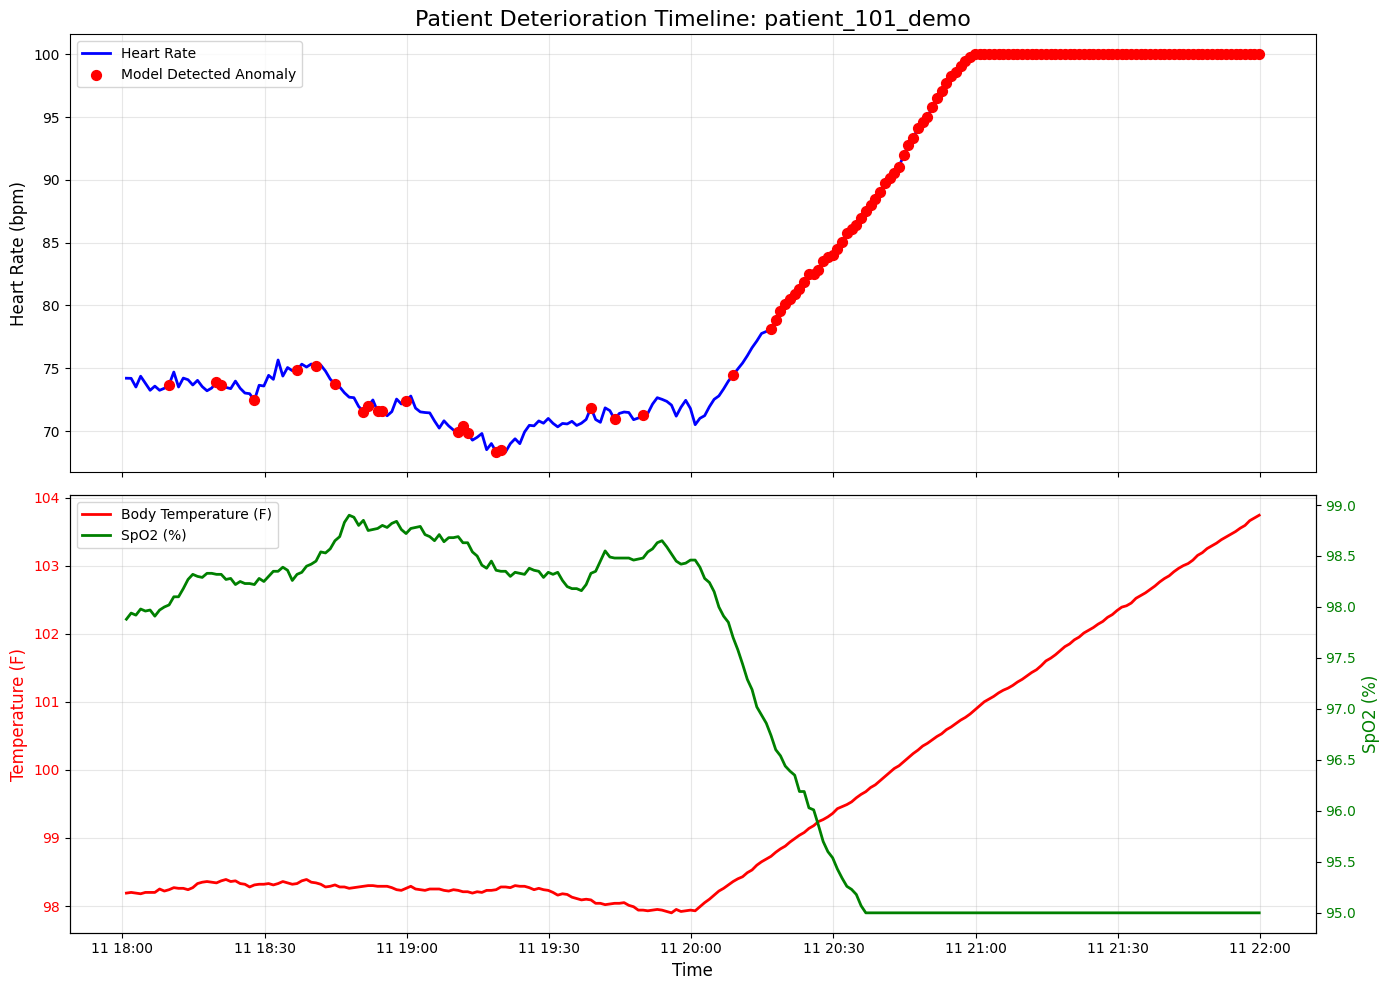

In [6]:
# Plotting the Patient's Journey
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot HR
ax1.plot(df_sick_stream.index, df_sick_stream['hr'], color='blue', label='Heart Rate', linewidth=2)
ax1.set_ylabel('Heart Rate (bpm)', fontsize=12)
ax1.set_title(f'Patient Deterioration Timeline: {person_id}', fontsize=16)

# Overlay Anomalies as Red Dots on HR graph
if anomalies_for_plotting:
    anomalous_hr_values = df_sick_stream.loc[anomalies_for_plotting, 'hr']
    ax1.scatter(anomalies_for_plotting, anomalous_hr_values, color='red', s=50, label='Model Detected Anomaly', zorder=5)

ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot Temp and SpO2
ax2.plot(df_sick_stream.index, df_sick_stream['temp'], color='red', label='Body Temperature (F)', linewidth=2)
ax2.set_ylabel('Temperature (F)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

ax3 = ax2.twinx()
ax3.plot(df_sick_stream.index, df_sick_stream['spo2'], color='green', label='SpO2 (%)', linewidth=2)
ax3.set_ylabel('SpO2 (%)', color='green', fontsize=12)
ax3.tick_params(axis='y', labelcolor='green')

# Combining legends for the bottom plot
lines, labels = ax2.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
ax3.legend(lines + lines2, labels + labels2, loc='upper left')

ax2.set_xlabel('Time', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
